In [8]:
pip install opencv-contrib-python scikit-image pywavelets matplotlib pandas scikit-learn

In [9]:
import cv2
import os
import numpy as np
import pywt
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.decomposition import PCA
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!ls "/content/drive/MyDrive/DIP Dataset 4 AT and T Dataset"

README	s11  s14  s17  s2   s22  s25  s28  s30	s33  s36  s39  s5  s8
s1	s12  s15  s18  s20  s23  s26  s29  s31	s34  s37  s4   s6  s9
s10	s13  s16  s19  s21  s24  s27  s3   s32	s35  s38  s40  s7


In [12]:
import cv2
import os
import numpy as np

dataset_path = "/content/drive/MyDrive/DIP Dataset 4 AT and T Dataset"

images = []
labels = []

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    # label comes from folder name s1, s2, s3...
    label = int(person.replace("s",""))

    for img_name in os.listdir(person_path):

        img_path = os.path.join(person_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        gray = cv2.resize(gray, (100,100))

        images.append(gray)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Total images loaded:", len(images))
print("Total labels:", len(labels))

Total images loaded: 400
Total labels: 400


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.5,
    stratify=labels,
    random_state=42
)

In [14]:
def compute_metrics(preds):

    acc = accuracy_score(y_test,preds)*100
    prec = precision_score(y_test,preds,average='macro')*100
    rec = recall_score(y_test,preds,average='macro')*100
    f1 = f1_score(y_test,preds,average='macro')*100

    return acc,prec,rec,f1

In [15]:
def image_quality(original, processed):

    original = original.astype(np.uint8)
    processed = processed.astype(np.uint8)

    p = psnr(original, processed, data_range=255)

    s, _ = ssim(original, processed, full=True, data_range=255)

    return p, s

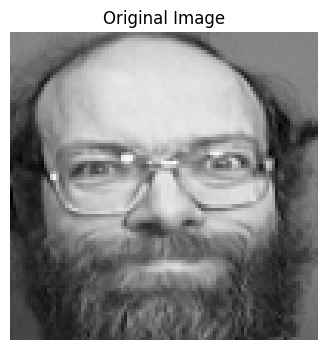

In [16]:
import matplotlib.pyplot as plt

sample = images[0]

plt.figure(figsize=(4,4))
plt.imshow(sample, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [17]:
def median_filter(img):
    return cv2.medianBlur(img,3)

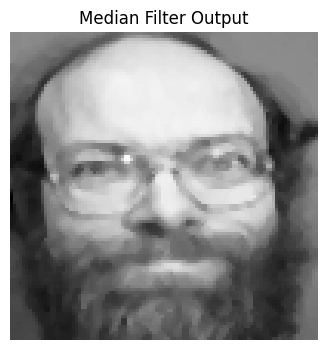

In [18]:
median_img = median_filter(sample)

plt.figure(figsize=(4,4))
plt.imshow(median_img, cmap='gray')
plt.title("Median Filter Output")
plt.axis("off")
plt.show()

In [19]:
def gray_normalization(img):

    norm = cv2.normalize(img,None,0,255,cv2.NORM_MINMAX)

    return norm

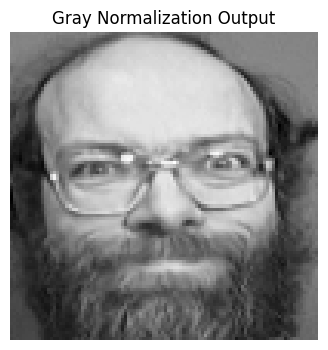

In [20]:
graynorm_img = gray_normalization(sample)

plt.figure(figsize=(4,4))
plt.imshow(graynorm_img, cmap='gray')
plt.title("Gray Normalization Output")
plt.axis("off")
plt.show()

In [21]:
def geometric_norm(img):

    rows,cols = img.shape

    M = cv2.getRotationMatrix2D((cols/2,rows/2),5,1)

    return cv2.warpAffine(img,M,(cols,rows))

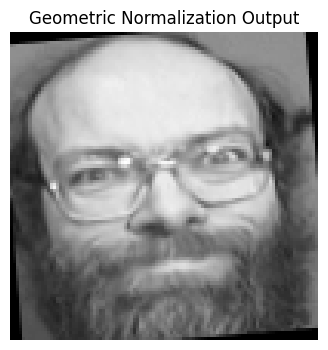

In [22]:
geom_img = geometric_norm(sample)

plt.figure(figsize=(4,4))
plt.imshow(geom_img, cmap='gray')
plt.title("Geometric Normalization Output")
plt.axis("off")
plt.show()

In [23]:
def wavelet_transform(img):

    coeffs = pywt.dwt2(img,'haar')

    LL,(LH,HL,HH) = coeffs

    return cv2.resize(LL,(100,100))

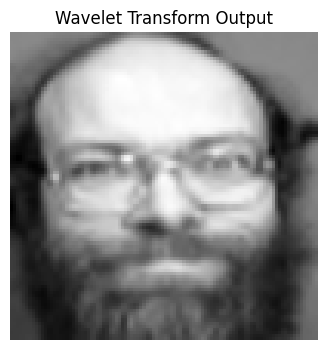

In [24]:
wavelet_img = wavelet_transform(sample)

plt.figure(figsize=(4,4))
plt.imshow(wavelet_img, cmap='gray')
plt.title("Wavelet Transform Output")
plt.axis("off")
plt.show()

In [25]:
def hist_eq(img):

    return cv2.equalizeHist(img)

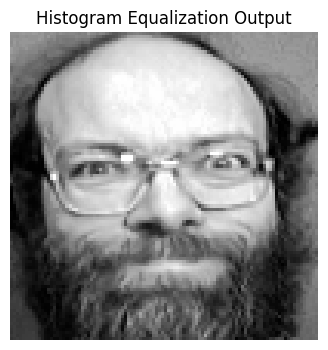

In [26]:
hist_img = hist_eq(sample)

plt.figure(figsize=(4,4))
plt.imshow(hist_img, cmap='gray')
plt.title("Histogram Equalization Output")
plt.axis("off")
plt.show()

In [27]:
methods = {
"Original":lambda x:x,
"Median":median_filter,
"GrayNorm":gray_normalization,
"Geometric":geometric_norm,
"Wavelet":wavelet_transform,
"Histogram":hist_eq,
}

results=[]
accuracies=[]

In [28]:
def flatten_images(images):

    flattened = []

    for img in images:
        flattened.append(img.flatten())

    return np.array(flattened)

In [29]:
results = []

for name, func in methods.items():

    # Apply preprocessing
    X_train_proc = np.array([func(img) for img in X_train])
    X_test_proc = np.array([func(img) for img in X_test])

    # Flatten images
    X_train_flat = flatten_images(X_train_proc)
    X_test_flat = flatten_images(X_test_proc)

    # PCA feature extraction
    pca = PCA(n_components=100)

    X_train_pca = pca.fit_transform(X_train_flat)
    X_test_pca = pca.transform(X_test_flat)

    # Train classifier
    model = SVC(kernel='linear')

    model.fit(X_train_pca, y_train)

    preds = model.predict(X_test_pca)

    # Compute recognition metrics
    acc, prec, rec, f1 = compute_metrics(preds)

    # Compute image quality metrics
    psnr_values = []
    ssim_values = []

    for i in range(len(X_test)):
        p, s = image_quality(X_test[i], X_test_proc[i])
        psnr_values.append(p)
        ssim_values.append(s)

    psnr_avg = np.mean(psnr_values)
    ssim_avg = np.mean(ssim_values)

    # Store results
    results.append([name, acc, prec, rec, f1, psnr_avg, ssim_avg])

    # Print results
    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("PSNR:", psnr_avg)
    print("SSIM:", ssim_avg)
    print("---------------------")

/usr/local/lib/python3.12/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


Original
Accuracy: 96.0
Precision: 96.89583333333334
Recall: 96.00000000000001
F1 Score: 95.93065268065268
PSNR: inf
SSIM: 1.0
---------------------
Median
Accuracy: 96.0
Precision: 96.89583333333334
Recall: 96.00000000000001
F1 Score: 95.93065268065268
PSNR: 35.01687306623634
SSIM: 0.9609218204535046
---------------------
GrayNorm
Accuracy: 97.0
Precision: 97.41071428571428
Recall: 97.00000000000001
F1 Score: 96.95707070707071
PSNR: 22.777049230733102
SSIM: 0.9636029988211037
---------------------
Geometric
Accuracy: 95.5
Precision: 96.72222222222221
Recall: 95.5
F1 Score: 95.44606782106781
PSNR: 19.811006254327822
SSIM: 0.6412478321516827
---------------------
Wavelet
Accuracy: 96.0
Precision: 96.89583333333334
Recall: 96.00000000000001
F1 Score: 95.93065268065268
PSNR: 8.91827059471163
SSIM: 0.3289917653074189
---------------------
Histogram
Accuracy: 95.0
Precision: 96.18154761904762
Recall: 95.0
F1 Score: 95.02787490287491
PSNR: 17.520827428695483
SSIM: 0.8262461918146239
--------

In [30]:
columns = ["Method","Accuracy","Precision","Recall","F1 Score","PSNR","SSIM"]

df = pd.DataFrame(results,columns=columns)

print(df)

      Method  Accuracy  Precision  Recall   F1 Score       PSNR      SSIM
0   Original      96.0  96.895833    96.0  95.930653        inf  1.000000
1     Median      96.0  96.895833    96.0  95.930653  35.016873  0.960922
2   GrayNorm      97.0  97.410714    97.0  96.957071  22.777049  0.963603
3  Geometric      95.5  96.722222    95.5  95.446068  19.811006  0.641248
4    Wavelet      96.0  96.895833    96.0  95.930653   8.918271  0.328992
5  Histogram      95.0  96.181548    95.0  95.027875  17.520827  0.826246


In [31]:
display(df)

,Method,Accuracy,Precision,Recall,F1 Score,PSNR,SSIM
0,Original,96.0,96.895833,96.0,95.930653,inf,1.000000
1,Median,96.0,96.895833,96.0,95.930653,35.016873,0.960922
2,GrayNorm,97.0,97.410714,97.0,96.957071,22.777049,0.963603
3,Geometric,95.5,96.722222,95.5,95.446068,19.811006,0.641248
4,Wavelet,96.0,96.895833,96.0,95.930653,8.918271,0.328992
5,Histogram,95.0,96.181548,95.0,95.027875,17.520827,0.826246


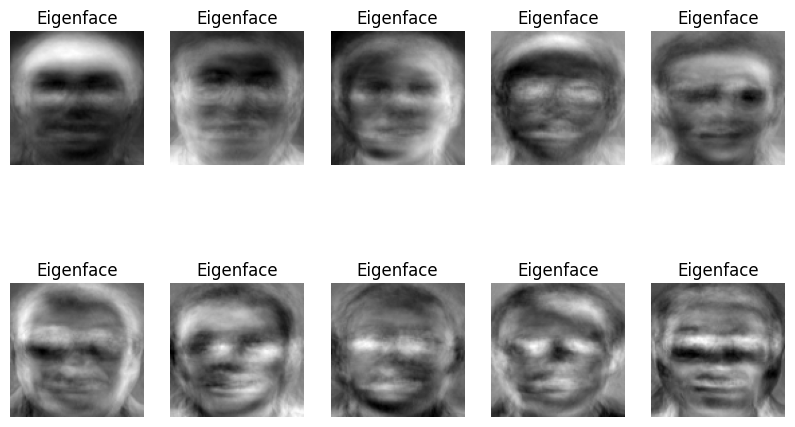

In [32]:
eigenfaces = pca.components_.reshape((100,100,100))

plt.figure(figsize=(10,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(eigenfaces[i], cmap='gray')
    plt.title("Eigenface")
    plt.axis('off')

plt.show()

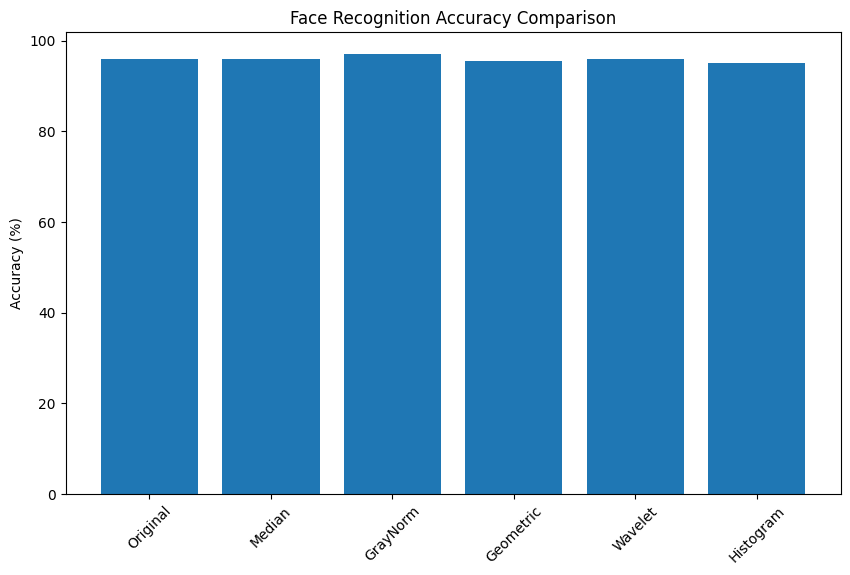

In [33]:
methods_list = [r[0] for r in results]
accuracies = [r[1] for r in results]

plt.figure(figsize=(10,6))
plt.bar(methods_list, accuracies)
plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Face Recognition Accuracy Comparison")
plt.show()

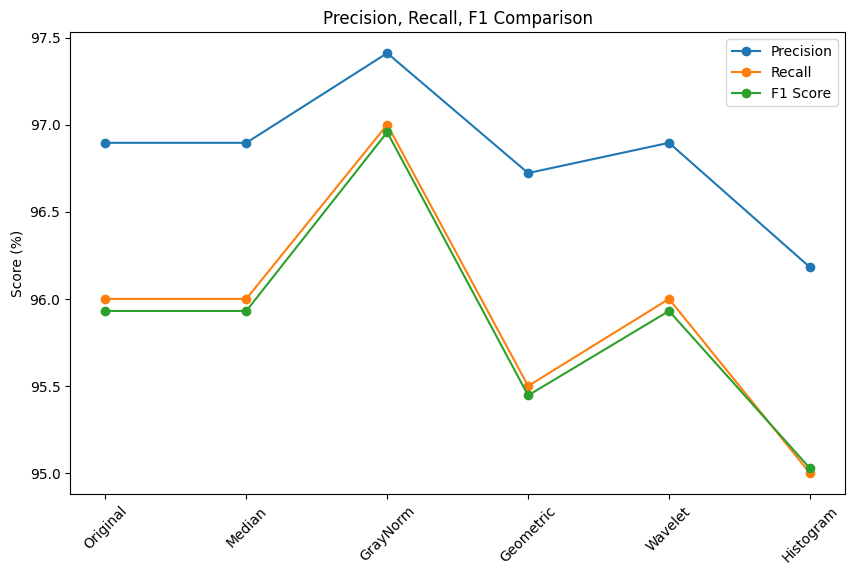

In [34]:
plt.figure(figsize=(10,6))

plt.plot(df["Method"], df["Precision"], marker='o', label="Precision")
plt.plot(df["Method"], df["Recall"], marker='o', label="Recall")
plt.plot(df["Method"], df["F1 Score"], marker='o', label="F1 Score")

plt.xticks(rotation=45)

plt.ylabel("Score (%)")
plt.title("Precision, Recall, F1 Comparison")

plt.legend()

plt.show()

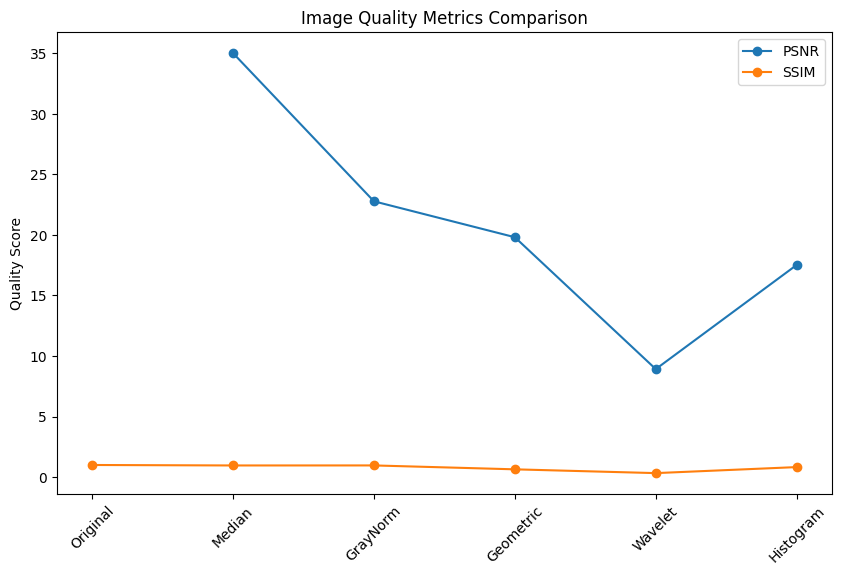

In [35]:
plt.figure(figsize=(10,6))

plt.plot(df["Method"], df["PSNR"], marker='o', label="PSNR")
plt.plot(df["Method"], df["SSIM"], marker='o', label="SSIM")

plt.xticks(rotation=45)

plt.ylabel("Quality Score")
plt.title("Image Quality Metrics Comparison")

plt.legend()

plt.show()

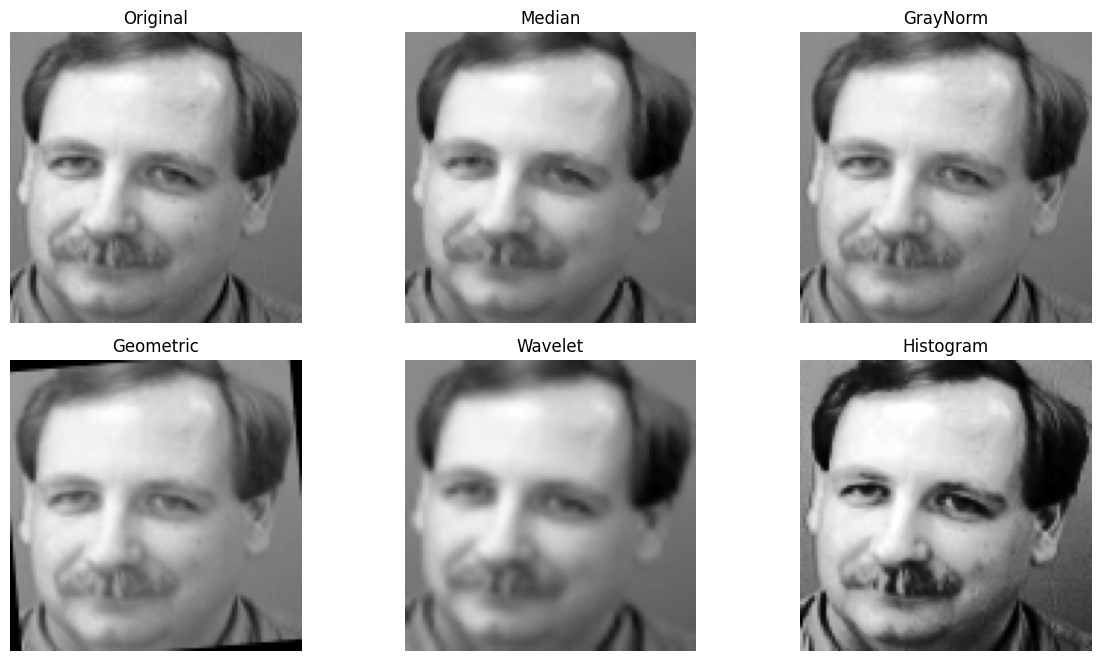

In [36]:
import matplotlib.pyplot as plt

sample = X_test[0]

plt.figure(figsize=(12,10))

# show original
plt.subplot(3,3,1)
plt.imshow(sample, cmap='gray')
plt.title("Original")
plt.axis("off")

i = 2

for name, func in methods.items():

    if name == "Original":
        continue

    processed = func(sample)

    plt.subplot(3,3,i)
    plt.imshow(processed, cmap='gray')
    plt.title(name)
    plt.axis("off")

    i += 1

plt.tight_layout()
plt.show()